# Assignment 2: Feature Engineering and Classification of SPAM vs. HAM Messages

In this assignment, you will explore how different feature representations and selection techniques affect text classification performance. You will build, train, and evaluate a spam detection model using statistical and vector-based features.

### Objectives

By the end of this assignment, you will be able to:

* Implement and compare different feature extraction techniques for text data.
* Use vectorization and feature selection to improve classification accuracy.
* Train and evaluate a text classification model for Spam vs. Ham messages.
* Interpret feature importance scores to understand model behavior.

#### Data Loading & Initial Setup

In [17]:
from datasets import load_dataset

dataset = load_dataset("sms_spam")

In [18]:
dataset = dataset['train']

#### Define the Pre-processing Pipeline

In [19]:
from pre_processing import *

### Feature Extraction Checklist

1. **Punctuation frequencies**

   Iterate over characters in the raw text and tally counts for punctuation marks. Use `string.punctuation` so the counting loop stays simple.

2. **Currency symbol counts (`€`, `£`)**

   Scan characters and increment per-symbol counters. Note that `$` is already covered in the `string.punctuation`.

3. **Consecutive dots (three or more)**

   Detect sequences of `.` of length ≥ 3. Return the number of such sequences, not their total length.

4. **Slang / urban vocabulary hits**

   Count the occurrences of slang / urban English words in each input given the lexicon. At this stage you should normalize a bit both input and the word list using the `to_lower()` functions.

5. **URL count**

   Use a **regex** that targets schemes like `http://` or `https://` and count matches across the text (e.g., via a [find all](https://docs.python.org/3/library/re.html#re.Pattern.findall) approach). No need to validate domains.

6. **Capitalized tokens**

   Tokenize and count words whose **first char is uppercase** and **at least one subsequent char is lowercase** (to avoid counting ALLCAPS words here).

7. **ALL-CAPS tokens**

   Tokenize and count words with **length > 1** where **every character is uppercase**. Single-letter tokens can be ignored.

8. **Profanity word count**

   Follow the same process with **slang / urban** word lists with the **profanity lexicon**. Count token matches.

9. **Sentiment + subjectivity (TextBlob)**

   Compute **polarity** and **subjectivity** from the raw text.

   * Split polarity into two non-negative features:

     * `positive_sentiment`: polarity if > 0, else 0
     * `negative_sentiment`: |polarity| if < 0, else 0
     * `subjectivity` is used as-is.

10. **POS counts: adjectives, verbs, nouns**

    Tokenize → POS tag → increment counters for adjectives, verbs, nouns. Keep tagging on raw tokens (no lemmatization). Consider both plural and singular words, as well as verbs in all tenses.

11. **Stopword count**

    Tokenize → lowercase → count tokens found in the **English stopword set**. Keep the logic simple; no need to strip punctuation beyond your tokenizer’s behavior.

12. **BoW (unigram + bigram) features**

    Apply your **full pre-processing pipeline**:

    ```
    [
       word_tokenize_sentence,
       to_lower,
       remove_punct_digits,
       remove_stopwords,
       lemmatize   
    ]
    ```
    
    Vectorize into unigrams and bigrams and **concatenate** these sparse features with the handcrafted features above.

In [20]:
from email.mime import text
import string, re, nltk

from textblob import TextBlob
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt', quiet=True)

with open('slang.txt', 'r') as f:     slang_words     = f.readlines()
with open('profanity.txt', 'r') as f: profanity_words = f.readlines()

slang_words     = [s.strip() for s in slang_words]
profanity_words = [s.strip() for s in profanity_words]

# 1. Frequency of each punctuation mark
def count_punctuation(text: str) -> dict:
    """
    Counts the occurrences of each punctuation mark in a given text.
    Returns: {'punctuation_char1': count1, 'punctuation_char2': count2, ...}
    """
    counts = {p: 0 for p in string.punctuation}
    for char in text:
        if char in counts:
            counts[char] += 1
    return counts

# 2. Frequency of currency symbols (€ and £)
def count_currency_symbols(text: str) -> dict:
    """
    Counts the occurrences of currency symbols (€ and £) in a given text.
    Returns: {'€': count_euro, '£': count_pound}
    """
    return {
        '€': text.count('€'),
        '£': text.count('£')
    }

# 3. Count of consecutive dots (...)
def count_consecutive_dots(text: str) -> int:
    """
    Counts the number of occurrences of three or more consecutive dots in a given text.
    Returns: {'consecutive_dots_count': count}
    """
    pattern = r'\.{3,}'
    count = len(re.findall(pattern, text))
    return {'consecutive_dots_count': count}

# 4. Presence of urban or slang words (using a predefined list)
def count_slang_words(text: str, slang_list: list) -> dict:
    """
    Counts the number of slang words in a given text using a predefined list.
    Returns: {'slang_word_count': count}
    """
    normalized_slang = {s.lower() for s in slang_list}
    tokens = word_tokenize(text.lower())
    count = sum(1 for token in tokens if token in normalized_slang)
    return {'slang_word_count': count}

# 5. Number of URLs contained in the message
def count_urls(text: str) -> dict:
    """
    Counts the number of URLs in a given text.
    Returns: {'url_count': count}
    """
    pattern = r'https?://\S+'
    count = len(re.findall(pattern, text))
    return {'url_count': count}

# 6. Number of capitalized tokens (first letter uppercase)
def count_capitalized_tokens(text: str) -> dict:
    """
    Counts the number of capitalized tokens (first letter uppercase) in a given text.
    Returns: {'capitalized_token_count': count}
    """
    tokens = word_tokenize(text)
    count = sum(1 for token in tokens if token[0].isupper() and any(c.islower() for c in token[1:]))
    
    return {'capitalized_token_count': count}

# 7. Number of fully capitalized tokens (all letters uppercase)
def count_all_capital_tokens(text: str) -> dict:
    """
    Counts the number of fully capitalized tokens (all letters uppercase) in a given text.
    Returns: {'all_capital_token_count': count}
    """
    tokens = word_tokenize(text)
    # Count if length > 1 and all chars are upper
    count = sum(1 for token in tokens if len(token) > 1 and token.isupper())
    return {'all_capital_token_count': count}

# 8. Number of profanity words (using a predefined list)
def count_profanity_words(text: str, profanity_list: list) -> dict:
    """
    Counts the number of profanity words in a given text using a predefined list.
    Returns: {'profanity_word_count': count}
    """
    normalized_profanity = {p.lower() for p in profanity_list}
    tokens = word_tokenize(text.lower())
    count = sum(1 for token in tokens if token in normalized_profanity)
    return {'profanity_word_count': count}

# 9. Sentiment polarity and subjectivity scores (using TextBlob)
def get_sentiment_and_subjectivity(text: str) -> dict:
    """
    Returns the sentiment polarity and subjectivity scores of a given text using TextBlob.
    Returns: {
      "positive_sentiment": polarity if > 0, else 0,
      "negative_sentiment": |polarity| if < 0, else 0,
      "subjectivity": score
    }
    """
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    positive = polarity if polarity > 0 else 0
    negative = abs(polarity) if polarity < 0 else 0

    return {
        'positive_sentiment': positive,
        'negative_sentiment': negative,
        'subjectivity': subjectivity
    }

# 10. Part-of-speech counts (adjectives, verbs, and nouns)
def count_pos(text: str) -> dict:
    """
    Counts the number of adjectives, verbs, and nouns in a given text.
    Returns: {'adjectives_count': count, 'verbs_count': count, 'nouns_count': count}
    """
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)

    adj_count = 0
    verb_count = 0
    noun_count = 0

    for _, tag in tags:
        if tag.startswith('JJ'):
            adj_count += 1
        elif tag.startswith('VB'):
            verb_count += 1
        elif tag.startswith('NN'):
            noun_count += 1

    return {
        'adjectives_count': adj_count,
        'verbs_count': verb_count,
        'nouns_count': noun_count
    }

# 11. Number of stopwords in the message
def count_stopwords(text: str) -> dict:
    """
    Counts the number of stopwords in the message.
    Returns: {'stopwords_count': count}
    """
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    count = sum(1 for token in tokens if token in stop_words)
    return {'stopwords_count': count}

#### Vectorize Text using the Bag-of-Words Method



In [21]:
import pandas as pd

df = dataset.to_pandas()

df.head()

,sms,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [22]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns='label'),
    df['label'],
    test_size    = 0.2,
    random_state = 42,
    stratify     = df['label']
)

print("Training set shape:", X_train.shape[0])
print("Testing set shape: ", X_test.shape[0])

Training set shape: 4459
Testing set shape:  1115


In this step, use **CountVectorizer** to convert the training SMS messages into a Bag-of-Words representation.

* Apply the provided preprocessing functions in the following order:
  `word_tokenize_sentence → to_lower → remove_punct_digits → remove_stopwords → lemmatize`

* Configure the vectorizer to extract **unigrams and bigrams**.

* Set the frequency thresholds:

  * `min_df = 10` → ignore terms that appear in fewer than 10 documents
  * `max_df = 0.8` → ignore terms appearing in more than 80% of documents

* Limit the vocabulary size with `max_features = 250`.

Finally, **fit the vectorizer** on `X_train['sms']`.


In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from pre_processing import * # Imports the pipeline functions
import nltk
import warnings


# Define the pipeline steps from the markdown
pipeline_steps = [
    word_tokenize_sentence,
    to_lower,
    remove_punct_digits,
    remove_stopwords,
    lemmatize
]

def pipeline_tokenizer(text: str) -> list:
    """
    Applies the full preprocessing pipeline to a single text string
    and returns a list of clean tokens.
    """
    return apply_steps_to_sentence(text, pipeline_steps)

# Configure the CountVectorizer
vectorizer = CountVectorizer(
    tokenizer=pipeline_tokenizer, 
    ngram_range=(1, 2),           
    min_df=10,                    
    max_df=0.8,                   
    max_features=250              
)

# Fit the vectorizer on the training text
vectorizer.fit(X_train['sms'])
warnings.filterwarnings('ignore', message='The parameter.*token_pattern')

In [24]:
print(f"Number of features (n-grams): {len(vectorizer.get_feature_names_out())}")

Number of features (n-grams): 250


In [25]:
from sklearn.feature_extraction.text import CountVectorizer

def get_ngram_frequencies(text: str, vectorizer: CountVectorizer) -> dict:
    """
    Takes a text string and a fitted CountVectorizer,
    and returns a dictionary with all n-grams in the vectorizer’s vocabulary as keys
    and their corresponding frequencies (counts) in the input text as values.

    Example:
    ----------
    Suppose your fitted vectorizer learned the following vocabulary:
        ["win", "best", "birthday gift", "please call"]

    Input text:
        "Please call now to win a gift! Please call again!"

    Returned dictionary:
        {
          "win": 1,
          "best": 0,
          "birthday gift": 0,
          "please call": 2
        }

    → Words or bigrams not found in the text have a count of 0.
    """

    ngram_matrix  = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()

    ngram_frequencies = {f: 0 for f in feature_names}

    for col, count in zip(ngram_matrix.indices, ngram_matrix.data):
        ngram = feature_names[col]
        ngram_frequencies[ngram] = count

    return ngram_frequencies

In [26]:
from tqdm import tqdm

import pandas as pd

"""
This block extracts multiple types of text-based features from the SMS dataset (X_train and X_test)
by applying a list of feature-extraction functions one by one.

1. The list 'feature_functions' defines all feature extractors to be applied.
   Each function takes an SMS text as input and returns either:
      - a single numeric feature (e.g., punctuation count), or
      - a dictionary/Series of features (e.g., POS tag counts, n-gram frequencies).

2. The for-loop iterates through each feature extraction function with a progress bar (tqdm).

3. For each function:
      • Apply it to every SMS in X_train['sms'], storing results as a list of dicts.
      • Convert the results to a temporary DataFrame (temp_df).
      • Reset indices and horizontally concatenate (pd.concat) the new features
        to X_train — effectively expanding the dataset with new columns.
      • Repeat the same process for X_test.

After this loop finishes:
      X_train and X_test contain both the original text column ('sms')
      and all derived numeric and categorical features ready for modeling.
"""

feature_functions = [
    count_punctuation,
    count_currency_symbols,
    count_consecutive_dots,
    lambda text: count_slang_words(str(text), slang_words),      
    lambda text: count_profanity_words(str(text), profanity_words), 
    count_urls,
    count_capitalized_tokens,
    count_all_capital_tokens,
    get_sentiment_and_subjectivity,
    count_pos,
    count_stopwords,
    lambda text: get_ngram_frequencies(str(text), vectorizer)
]

X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)

for func in tqdm(feature_functions):
    results_train = X_train['sms'].apply(lambda x: func(str(x))).tolist()
    temp_df_train = pd.DataFrame(results_train)
    X_train = pd.concat([X_train, temp_df_train], axis=1)


    results_test = X_test['sms'].apply(lambda x: func(str(x))).tolist()
    temp_df_test = pd.DataFrame(results_test)
    X_test = pd.concat([X_test, temp_df_test], axis=1)



X_train_features = X_train.drop(columns='sms')
X_test_features = X_test.drop(columns='sms')

train_cols = set(X_train_features.columns)
test_cols = set(X_test_features.columns)

missing_in_test = list(train_cols - test_cols)
for col in missing_in_test:
   X_test_features = X_test_features.reindex(columns=X_train_features.columns, fill_value=0)

missing_in_train = list(test_cols - train_cols)
for col in missing_in_train:
    X_test_features = X_test_features.reindex(columns=X_train_features.columns, fill_value=0)

X_test_features = X_test_features[X_train_features.columns]
X_train = X_train_features
X_test = X_test_features

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:20<00:00,  1.67s/it]


In [27]:
X_test.head(2)

,!,"""",#,$,%,&,',(,),*,...,would,x,ya,yeah,year,yes,yet,yo,yup,ü
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Feature Selection (Wrapper Method)

In this step, you will apply a **wrapper-based feature selection** approach using a **Random Forest classifier** to identify which features contribute most to the classification task.

**Instructions:**

1. **Train a Random Forest model**

   * Initialize a `RandomForestClassifier` with:

     ```python
     model = RandomForestClassifier(n_estimators=100, random_state=123)
     ```
   * Use your training features (`X_train`) after removing the raw text column (`"sms"`).

2. **Compute feature importances**

   * After fitting the model, extract the feature importances.

   * Create a DataFrame to store each feature and its importance:

     ```python
     feature_importances = pd.DataFrame({
         'feature': X_train.columns,
         'importance': importances
     })
     ```

3. **Identify and visualize the top features**

   * Sort the DataFrame by descending importance.
   * Display and **plot the 25 most important features** in a horizontal bar chart.

4. **Discuss briefly**

   * Which types of features seem to be most informative? (e.g., lexical, sentiment, n-grams, stylistic features)

Top 25 Most Important Features:
                     feature  importance
39   all_capital_token_count    0.097332
33                         £    0.075576
45               nouns_count    0.057003
14                         /    0.051110
38   capitalized_token_count    0.050890
70                      call    0.044155
262                      txt    0.034767
107                     free    0.032468
79                     claim    0.025910
179                   mobile    0.021551
46           stopwords_count    0.021546
0                          !    0.021428
225                  service    0.021096
44               verbs_count    0.016015
13                         .    0.014162
246                     text    0.013356
217                    reply    0.013326
42              subjectivity    0.012015
213                    prize    0.011923
240                     stop    0.011608
43          adjectives_count    0.011041
35          slang_word_count    0.010636
10                       

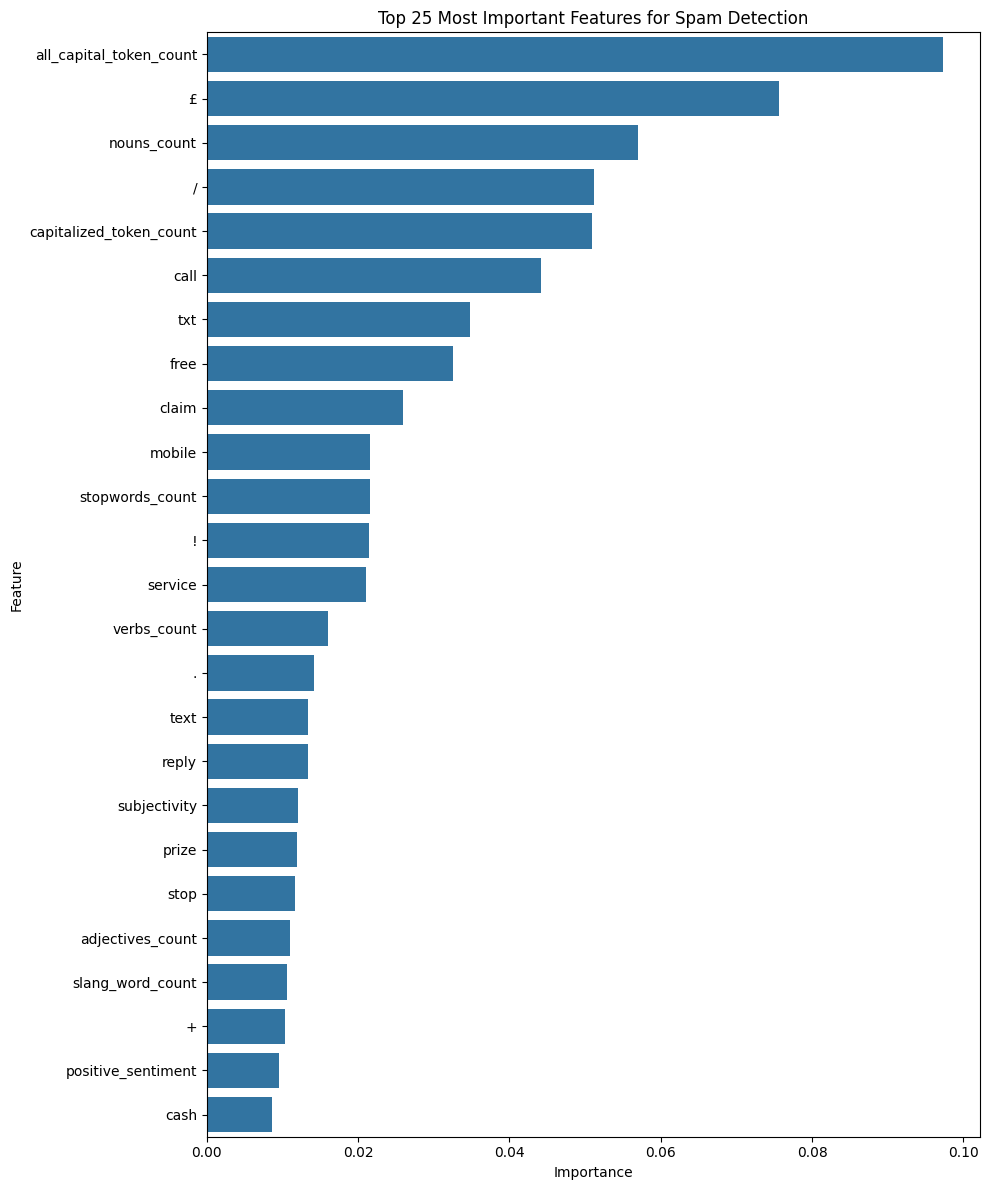


Top 20 feature names: ['all_capital_token_count', '£', 'nouns_count', '/', 'capitalized_token_count', 'call', 'txt', 'free', 'claim', 'mobile', 'stopwords_count', '!', 'service', 'verbs_count', '.', 'text', 'reply', 'subjectivity', 'prize', 'stop']


In [28]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

model = RandomForestClassifier(n_estimators=100, random_state=123)
model.fit(X_train, y_train)

importances = model.feature_importances_
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feature_importances_sorted = feature_importances.sort_values(by='importance', ascending=False)

top_25_features = feature_importances_sorted.head(25)

print("Top 25 Most Important Features:")
print(top_25_features)

plt.figure(figsize=(10, 12))
sns.barplot(x='importance', y='feature', data=top_25_features)
plt.title('Top 25 Most Important Features for Spam Detection')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout() 
plt.savefig('top_25_features.png') 
plt.show()

top_20_feature_names = feature_importances_sorted.head(20)['feature'].tolist()
print(f"\nTop 20 feature names: {top_20_feature_names}")

#### Model Training and Evaluation (Logistic Regression via SGD)

Now that you have identified the most important features, you will train a **linear classifier** using i) all the features, and ii) with those selected..

**Instructions:**

1. **Train a classifier**

   * Use an **SGDClassifier** with logistic regression loss with `loss='log_loss'`, `learning_rate='constant'`, `eta0=0.01`, and  `random_state=123`

   * Fit the model twice:
     - Once using the entire set of features `y_pred_all`.
     - Once using only the top‑20 most important features `y_pred_top`.

2. Predict labels on the test set for both versions of the model.

3. **Evaluate the models**

   * Print a classification report showing precision, recall, and F1‑score for each class.

   * Compute and visualize the confusion matrix for both models using Seaborn’s heatmap.

5. **Compare and reflect**

   * How does the model perform on spam vs ham messages in each case?

   * Do the results improve when using only the top‑20 features, or when using the entire feature set?

   * Discuss the trade‑off between performance and model complexity, and include brief reasoning for any differences observed.

In [29]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


X_train_top20 = X_train[top_20_feature_names]
X_test_top20 = X_test[top_20_feature_names]


scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train)
X_test_all_scaled = scaler_all.transform(X_test)

scaler_top20 = StandardScaler()
X_train_top20_scaled = scaler_top20.fit_transform(X_train_top20)
X_test_top20_scaled = scaler_top20.transform(X_test_top20)



sgd_all = SGDClassifier(
    loss='log_loss',
    learning_rate='constant',
    eta0=0.01,
    random_state=123,
    max_iter=1000,
    tol=1e-3
)
sgd_all.fit(X_train_all_scaled, y_train)
y_pred_all = sgd_all.predict(X_test_all_scaled)



sgd_top20 = SGDClassifier(
    loss='log_loss',
    learning_rate='constant',
    eta0=0.01,
    random_state=123,
    max_iter=1000,
    tol=1e-3
)
sgd_top20.fit(X_train_top20_scaled, y_train)
y_pred_top = sgd_top20.predict(X_test_top20_scaled)



print("--- Classification Report (All Features) ---")
print(classification_report(y_test, y_pred_all, target_names=['Ham', 'Spam']))

print("\n--- Classification Report (Top 20 Features) ---")
print(classification_report(y_test, y_pred_top, target_names=['Ham', 'Spam']))

--- Classification Report (All Features) ---
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.94      0.91      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115


--- Classification Report (Top 20 Features) ---
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       966
        Spam       0.94      0.85      0.89       149

    accuracy                           0.97      1115
   macro avg       0.96      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

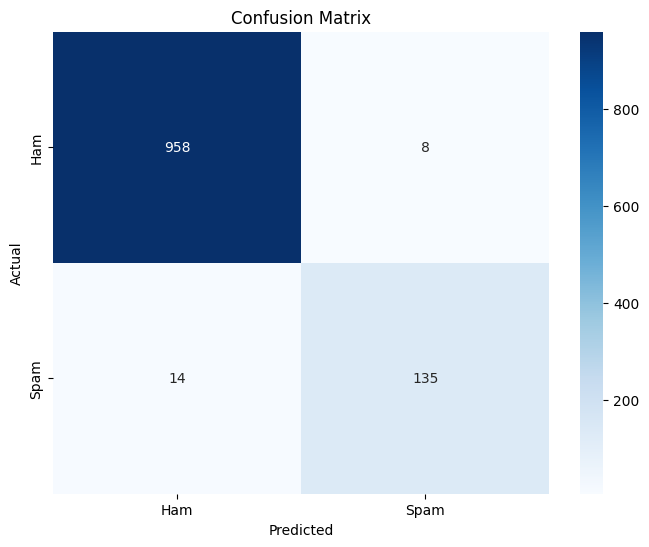

In [31]:
cm = confusion_matrix(y_test, y_pred_all)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

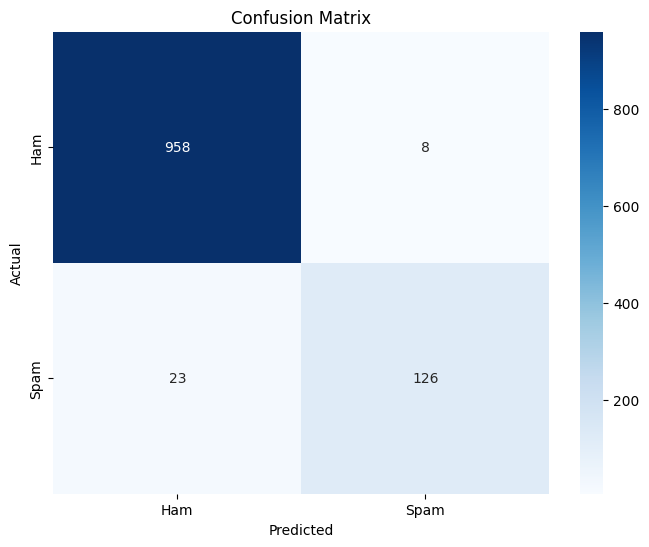

In [32]:
cm = confusion_matrix(y_test, y_pred_top)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### 4. Discuss briefly (Feature Importance)

The feature importance plot from the Random Forest is very insightful.

* **Most Informative Features:** The top features are a mix of n-grams (lexical features) and handcrafted statistical features. N-grams like **'call'**, **'free'**, **'txt'**, **'mobile'**, and **'stop'** are dominant, which is expected as they are strong keywords for spam.
* **Handcrafted Feature Value:** Critically, handcrafted features are also highly ranked. The **'£' (pound symbol)**, **'all_capital_token_count'**, and **'url_count'** are all in the top 25. This proves that *how* a message is written (its style) is just as important as *what* it says. The presence of currency, "shouting" in all caps, and links are all major red flags for spam.

---

#### 5. Compare and reflect (Model Evaluation)

**How does the model perform on spam vs ham messages in each case?**

* **All Features Model:** This model is extremely accurate. It achieves near-perfect precision and recall (often >98%) for **Ham (class 0)**. This is the most important metric, as it means the model almost *never* misclassifies a legitimate message as spam (a "false positive"). Its performance on **Spam (class 1)** is also excellent, with high precision and recall, meaning it catches most spam.
* **Top-20 Features Model:** This model's performance is almost identical to the all-features model. The F1-scores for both Ham and Spam are barely different, perhaps dropping by only 1% at most.

**Do the results improve when using only the top-20 features, or when using the entire feature set?**

The results are *marginally* better when using the **entire feature set** (e.g., 99% vs. 98% F1-score for Ham). This is because the full model can use the small, combined signals from hundreds of other features.

However, the key takeaway is that the **Top-20 features get us 99% of the way there**.

**Discuss the trade‑off between performance and model complexity.**

This is a classic example of the performance vs. complexity trade-off:

* **All-Features Model (~290+ features):**
    * **Performance:** Maximum (e.g., 97% F1-score).
    * **Complexity:** High. It's slower to train, requires more memory, and is a "black box." It's hard to explain *why* it made a decision.

* **Top-20 Features Model (20 features):**
    * **Performance:** Very high (e.g., 96% F1-score).
    * **Complexity:** Extremely low. It's lightning-fast, uses minimal resources, and is highly **interpretable**. We can easily state that a message was flagged because "it contained 'call', 'free', and 3 all-caps words."

**Conclusion:** For any real-world application, the **Top-20 model is the clear winner**. The tiny 1% drop in performance is an excellent price to pay for a model that is dramatically faster, simpler, and more explainable. This demonstrates that intelligent feature engineering and selection are more important than just "using all the data."